In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from IPython.display import display, display_html

# Set style & palette
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid')

# Distinct palette colors
CB_PALETTE = ['#0072B2', '#009E73', '#D55E00', '#CC79A7']
sns.set_palette(CB_PALETTE)

# Custom color mapping for consistency across all plots
COLOR_MAP = {
    'CubeMX v2.2 (Nucleo)': '#0072B2',
    'AI Studio v4.0 (Nucleo)': '#009E73',
    'DevCloud v2.2 (DK)': '#D55E00',
    'DevCloud v4.0 (DK)': '#CC79A7'
}

# Resolved relative to the notebook's location (Report/)
PLOT_DIR = 'plot'
os.makedirs(PLOT_DIR, exist_ok=True)

In [2]:
# Load Baseline files (relative to Report/ directory)
df_base_aistudio = pd.read_csv('../Results/baseline/performance_baseline_results_aistudio.csv')
df_base_cubemx = pd.read_csv('../Results/baseline/performance_baseline_results_cubemx.csv')
df_base_cloud2 = pd.read_csv('../Results/baseline/performance_baseline_results_devcloudaicore2.2.csv')
df_base_cloud4 = pd.read_csv('../Results/baseline/performance_baseline_results_devcloudaicore4.0.csv')

# Load Estimated files (relative to Report/ directory)
df_est_aistudio = pd.read_csv('../Results/estimated/performance_estimated_results_aistudio.csv')
df_est_cubemx = pd.read_csv('../Results/estimated/performance_estimated_results_cubemx.csv')
df_est_cloud2 = pd.read_csv('../Results/estimated/performance_estimated_results_devcloudaicore2.2.csv')
df_est_cloud4 = pd.read_csv('../Results/estimated/performance_estimated_results_devcloudaicore4.0.csv')

# Standardize Model Names across datasets to prevent mismatches
for df in [df_base_aistudio, df_base_cubemx, df_base_cloud2, df_base_cloud4,
           df_est_aistudio, df_est_cubemx, df_est_cloud2, df_est_cloud4]:
    if 'Model Name' in df.columns:
        df['Model Name'] = df['Model Name'].str.replace('conv2d_poll', 'conv2d_pool')

# Data cleaning: convert columns to numeric for baseline data
for df in [df_base_aistudio, df_base_cubemx, df_base_cloud2, df_base_cloud4]:
    if 'Inference Time (ms)' in df.columns:
        df['Inference Time (ms)'] = pd.to_numeric(df['Inference Time (ms)'], errors='coerce')
    if 'RAM Usage (KiB)' in df.columns:
        df['RAM Usage (KiB)'] = pd.to_numeric(df['RAM Usage (KiB)'], errors='coerce')
    if 'Flash Usage (KiB)' in df.columns:
        df['Flash Usage (KiB)'] = pd.to_numeric(df['Flash Usage (KiB)'], errors='coerce')

# Map raw model names to formatted labels for presentation
def get_clean_name(model_name):
    if not isinstance(model_name, str):
        return model_name
    name = model_name.replace('baseline_', '').replace('_int8', '')
    if name == 'conv2d_pool':
        return 'Conv2D + MaxPool'
    if name == 'depthwise_3x3':
        return 'Depthwise Conv2D 3x3'
    if name == 'conv2d_3x3':
        return 'Conv2D 32f 3x3'
    if name == 'conv2d_16f_3x3':
        return 'Conv2D 16f 3x3'
    if name == 'conv2d_64f_3x3':
        return 'Conv2D 64f 3x3'
    if name == 'conv2d_1x1':
        return 'Conv2D 32f 1x1'
    if name == 'conv2d_32f_5x5':
        return 'Conv2D 32f 5x5'
    if name == 'conv2d_32f_7x7':
        return 'Conv2D 32f 7x7'
    return name

## 1. Tested Models and Platforms
This section describes the single-layer models selected for benchmarking and the hardware/software configurations tested.

### Benchmark Platforms & Configurations:
- **AI Studio v4.0 (Nucleo):** STM32 AI Studio running **AI Core v4.0** compiler on the STM32N6 Nucleo hardware board.
- **CubeMX v2.2 (Nucleo):** STM32CubeMX with X-CUBE-AI running **AI Core v2.2** compiler on the STM32N6 Nucleo hardware board.
- **DevCloud v2.2 (DK):** ST DevCloud running **AI Core v2.2** compiler on the STM32N6 Discovery Kit (DK) board.
- **DevCloud v4.0 (DK):** ST DevCloud running **AI Core v4.0** compiler on the STM32N6 Discovery Kit (DK) board.

In [3]:
# Compile Table of Tested Models
overview_models = df_base_aistudio[['Model Name', 'Layer Type', 'Filters', 'Kernel Size', 'Input Shape', 'Quantization', 'MACC']].copy()
overview_models['Clean Name'] = overview_models['Model Name'].apply(get_clean_name)

# Reorder columns
overview_models = overview_models[['Model Name', 'Clean Name', 'Layer Type', 'Filters', 'Kernel Size', 'Input Shape', 'Quantization', 'MACC']]

# Style and display
styled_models = overview_models.style.set_properties(**{
    'text-align': 'center',
    'font-size': '11pt',
    'border': '1px solid lightgrey'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#34495e'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]}
]).set_caption("Summary of Tested Models and Operators")

display(styled_models)

,Model Name,Clean Name,Layer Type,Filters,Kernel Size,Input Shape,Quantization,MACC
0,baseline_conv2d_16f_3x3_int8,Conv2D 16f 3x3,Conv2D,16,3x3,64x64x3,INT8,1835024
1,baseline_conv2d_1x1_int8,Conv2D 32f 1x1,Conv2D (Pointwise),32,1x1,64x64x3,INT8,524320
2,baseline_conv2d_32f_5x5_int8,Conv2D 32f 5x5,Conv2D,32,5x5,64x64x3,INT8,9961504
3,baseline_conv2d_32f_7x7_int8,Conv2D 32f 7x7,Conv2D,32,7x7,64x64x3,INT8,19398688
4,baseline_conv2d_3x3_int8,Conv2D 32f 3x3,Conv2D,32,3x3,64x64x3,INT8,3670048
5,baseline_conv2d_64f_3x3_int8,Conv2D 64f 3x3,Conv2D,64,3x3,64x64x3,INT8,7340096
6,baseline_conv2d_pool_int8,Conv2D + MaxPool,Conv2D + MaxPool,16,3x3,64x64x3,INT8,1851408
7,baseline_depthwise_3x3_int8,Depthwise Conv2D 3x3,DepthwiseConv2D,3,3x3,64x64x3,INT8,122883


## 2. Inference Time Comparison (Table & Bar Plot)
This section evaluates the execution speed across all four compilers and platforms. 
- **FAIL** denotes hardware timeout, out of memory, or model compilation failure.
- The plots use highly distinct, custom colors for visual clarity.

,CubeMX v2.2 (Nucleo),AI Studio v4.0 (Nucleo),DevCloud v2.2 (DK),DevCloud v4.0 (DK)
Model,,,,
Depthwise Conv2D 3x3,0.042 ms,0.053 ms,0.050 ms,0.031 ms
Conv2D 16f 3x3,0.079 ms,0.122 ms,0.087 ms,0.086 ms
Conv2D + MaxPool,0.080 ms,0.121 ms,0.087 ms,0.088 ms
Conv2D 32f 1x1,0.146 ms,0.373 ms,0.153 ms,0.288 ms
Conv2D 32f 3x3,0.147 ms,0.208 ms,0.155 ms,0.155 ms
Conv2D 32f 5x5,0.154 ms,0.219 ms,0.161 ms,0.161 ms
Conv2D 64f 3x3,0.284 ms,0.383 ms,0.291 ms,0.291 ms
Conv2D 32f 7x7,0.462 ms,FAIL,0.473 ms,FAIL


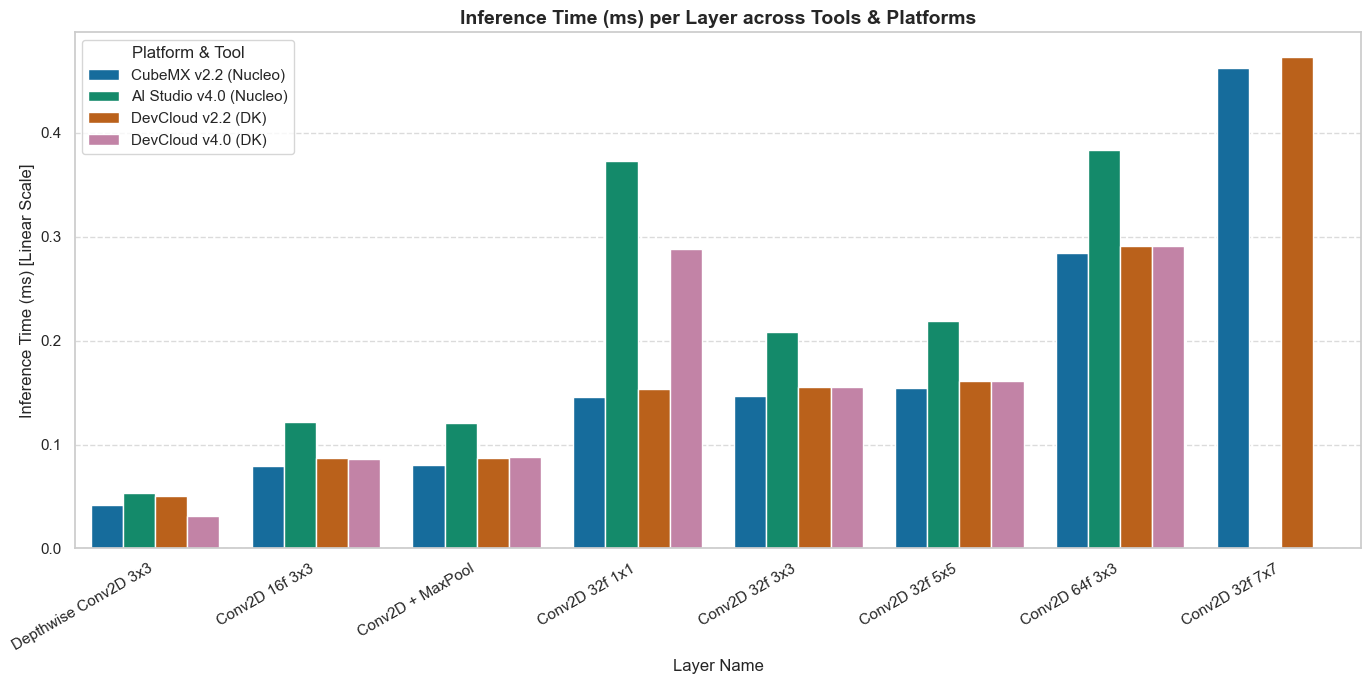

In [4]:
# Consolidated Inference Time Table
dfs_base = {
    'CubeMX v2.2 (Nucleo)': df_base_cubemx,
    'AI Studio v4.0 (Nucleo)': df_base_aistudio,
    'DevCloud v2.2 (DK)': df_base_cloud2,
    'DevCloud v4.0 (DK)': df_base_cloud4
}

inference_data = []
all_models = df_base_aistudio['Model Name'].unique()

for m in all_models:
    row_data = {'Model': get_clean_name(m)}
    for tool_name, df in dfs_base.items():
        row_match = df[df['Model Name'] == m]
        if not row_match.empty:
            val = row_match.iloc[0]['Inference Time (ms)']
            row_data[tool_name] = val
        else:
            row_data[tool_name] = np.nan
    inference_data.append(row_data)

df_inference_table = pd.DataFrame(inference_data).set_index('Model')

# Reorder columns
col_order_tools = ['CubeMX v2.2 (Nucleo)', 'AI Studio v4.0 (Nucleo)', 'DevCloud v2.2 (DK)', 'DevCloud v4.0 (DK)']
df_inference_table = df_inference_table.reindex(columns=col_order_tools)

# Sort index logically by model size
model_order = [
    'Depthwise Conv2D 3x3', 'Conv2D 16f 3x3', 'Conv2D + MaxPool',
    'Conv2D 32f 1x1', 'Conv2D 32f 3x3', 'Conv2D 32f 5x5',
    'Conv2D 64f 3x3', 'Conv2D 32f 7x7'
]
df_inference_table = df_inference_table.reindex([m for m in model_order if m in df_inference_table.index])

# Formatted table for printing
df_inference_print = df_inference_table.apply(lambda col: col.map(lambda x: f"{x:.3f} ms" if not pd.isna(x) else "FAIL"))

styled_inference = df_inference_print.style.set_properties(**{
    'text-align': 'center',
    'font-size': '11pt',
    'border': '1px solid lightgrey'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2980b9'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]}
]).set_caption("Measured Inference Time (ms) across Compilers and Boards")

display(styled_inference)

# Plotting the inference times as a bar plot
plt.figure(figsize=(14, 7))
data_list = []
for tool, df in dfs_base.items():
    for _, row in df.iterrows():
        clean_model = get_clean_name(row['Model Name'])
        val = row['Inference Time (ms)']
        data_list.append({
            'Tool': tool,
            'Model Name': clean_model,
            'Inference Time (ms)': val
        })
df_all = pd.DataFrame(data_list)

sns.barplot(data=df_all, x='Model Name', y='Inference Time (ms)', hue='Tool', palette=COLOR_MAP, order=model_order)
plt.title('Inference Time (ms) per Layer across Tools & Platforms', fontweight='bold', fontsize=14)
plt.ylabel('Inference Time (ms) [Linear Scale]', fontsize=12)
plt.xlabel('Layer Name', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Platform & Tool', frameon=True)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/11_inference_time_bar_plot.png', dpi=300)
plt.show()

## 3. Memory Footprint: Compiler Estimated vs. Actual Hardware RAM Usage
Here we compare the **Estimated RAM** against the **Actual RAM** using distinct color scales:
- **Logarithmic scale** is used to handle large variations (e.g. from 12 KiB to 1548 KiB).
- **Shared Y-axis scale** is applied to directly expose discrepancies, highlighting cases where compilers severely underestimate actual memory limits (e.g. 7x7 layer on CubeMX).

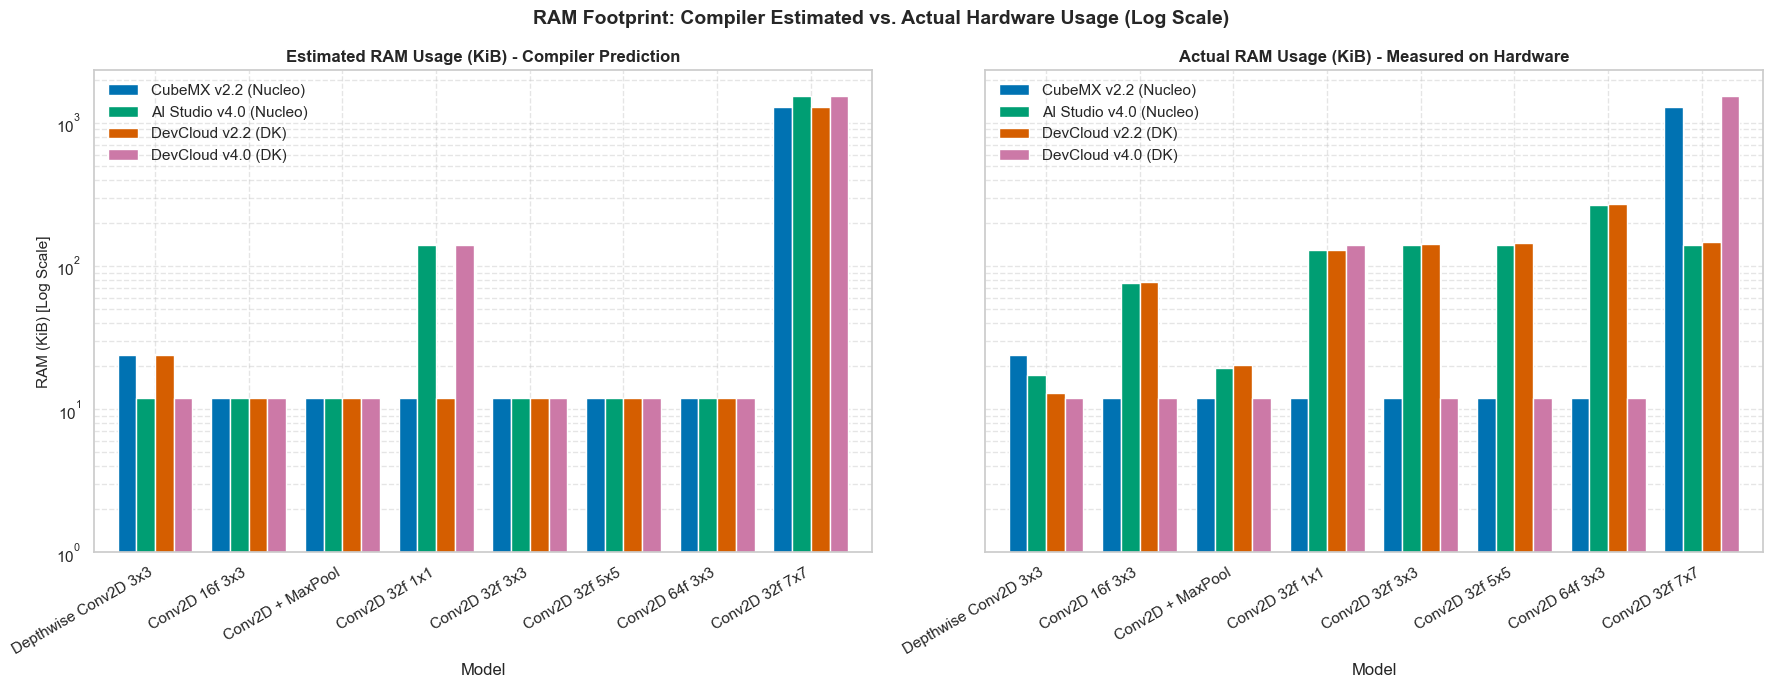

,CubeMX v2.2 (Nucleo),AI Studio v4.0 (Nucleo),DevCloud v2.2 (DK),DevCloud v4.0 (DK)
Model,,,,
Depthwise Conv2D 3x3,24.00,12.00,24.00,12.00
Conv2D 16f 3x3,12.02,12.02,12.02,12.02
Conv2D + MaxPool,12.02,12.02,12.02,12.02
Conv2D 32f 1x1,12.03,140.00,12.03,140.00
Conv2D 32f 3x3,12.03,12.03,12.03,12.03
Conv2D 32f 5x5,12.03,12.03,12.03,12.03
Conv2D 64f 3x3,12.06,12.06,12.06,12.06
Conv2D 32f 7x7,1292.00,1546.24,1290.24,1546.24


,CubeMX v2.2 (Nucleo),AI Studio v4.0 (Nucleo),DevCloud v2.2 (DK),DevCloud v4.0 (DK)
Model,,,,
Depthwise Conv2D 3x3,24.00,17.34,13.07,12.00
Conv2D 16f 3x3,12.02,76.28,77.20,12.02
Conv2D + MaxPool,12.02,19.30,20.22,12.02
Conv2D 32f 1x1,12.03,130.26,130.34,140.00
Conv2D 32f 3x3,12.03,140.42,142.28,12.03
Conv2D 32f 5x5,12.03,140.61,145.47,12.03
Conv2D 64f 3x3,12.06,268.70,272.44,12.06
Conv2D 32f 7x7,1292.00,140.92,146.06,1548.00


In [5]:
# Prepare RAM data
ram_data_est = []
ram_data_act = []

dfs_est = {
    'CubeMX v2.2 (Nucleo)': df_est_cubemx,
    'AI Studio v4.0 (Nucleo)': df_est_aistudio,
    'DevCloud v2.2 (DK)': df_est_cloud2,
    'DevCloud v4.0 (DK)': df_est_cloud4
}

for m in all_models:
    clean_m = get_clean_name(m)
    
    # Estimated
    est_row = {'Model': clean_m}
    for tool_name, df in dfs_est.items():
        row_match = df[df['Model Name'] == m]
        val = row_match.iloc[0]['Estimated RAM Usage (KiB)'] if not row_match.empty else np.nan
        est_row[tool_name] = val
    ram_data_est.append(est_row)
    
    # Actual
    act_row = {'Model': clean_m}
    for tool_name, df in dfs_base.items():
        row_match = df[df['Model Name'] == m]
        val = row_match.iloc[0]['RAM Usage (KiB)'] if not row_match.empty else np.nan
        act_row[tool_name] = val
    ram_data_act.append(act_row)

df_ram_est = pd.DataFrame(ram_data_est).set_index('Model').reindex(columns=col_order_tools)
df_ram_act = pd.DataFrame(ram_data_act).set_index('Model').reindex(columns=col_order_tools)

df_ram_est = df_ram_est.reindex([m for m in model_order if m in df_ram_est.index])
df_ram_act = df_ram_act.reindex([m for m in model_order if m in df_ram_act.index])

# Plotting side-by-side with custom colors
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
colors_ram = [COLOR_MAP[col] for col in df_ram_est.columns]

df_ram_est.plot(kind='bar', ax=axes[0], width=0.8, color=colors_ram)
axes[0].set_title('Estimated RAM Usage (KiB) - Compiler Prediction', fontweight='bold', fontsize=12)
axes[0].set_ylabel('RAM (KiB) [Log Scale]', fontsize=11)
axes[0].set_yscale('log')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].grid(True, which="both", ls="--", alpha=0.5)

df_ram_act.plot(kind='bar', ax=axes[1], width=0.8, color=colors_ram)
axes[1].set_title('Actual RAM Usage (KiB) - Measured on Hardware', fontweight='bold', fontsize=12)
axes[1].set_yscale('log')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].grid(True, which="both", ls="--", alpha=0.5)

# Set same y-limit
max_val = max(df_ram_est.max().max(), df_ram_act.max().max())
axes[0].set_ylim(1, max_val * 1.5)
axes[1].set_ylim(1, max_val * 1.5)

plt.suptitle('RAM Footprint: Compiler Estimated vs. Actual Hardware Usage (Log Scale)', fontweight='bold', fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/9_ram_estimated_vs_actual_side_by_side.png', dpi=300)
plt.show()

# Display tables stacked vertically for proper PDF formatting (avoid horizontal clipping)
html_est = df_ram_est.style.set_caption("Estimated RAM Usage (KiB)").format(precision=2).set_properties(**{'text-align': 'center'}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#8e44ad'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]}
]).to_html()

html_act = df_ram_act.style.set_caption("Actual RAM Usage (KiB)").format(precision=2).set_properties(**{'text-align': 'center'}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]}
]).to_html()

display_html(html_est, raw=True)
display_html("<br>", raw=True)
display_html(html_act, raw=True)

## 4. Operation Complexity: Compiler Estimated vs. Actual Hardware MACC
Below is the comparison of **Estimated MACC** vs. **Actual MACC** count for all models across compilers. Linear scale is used for readability.

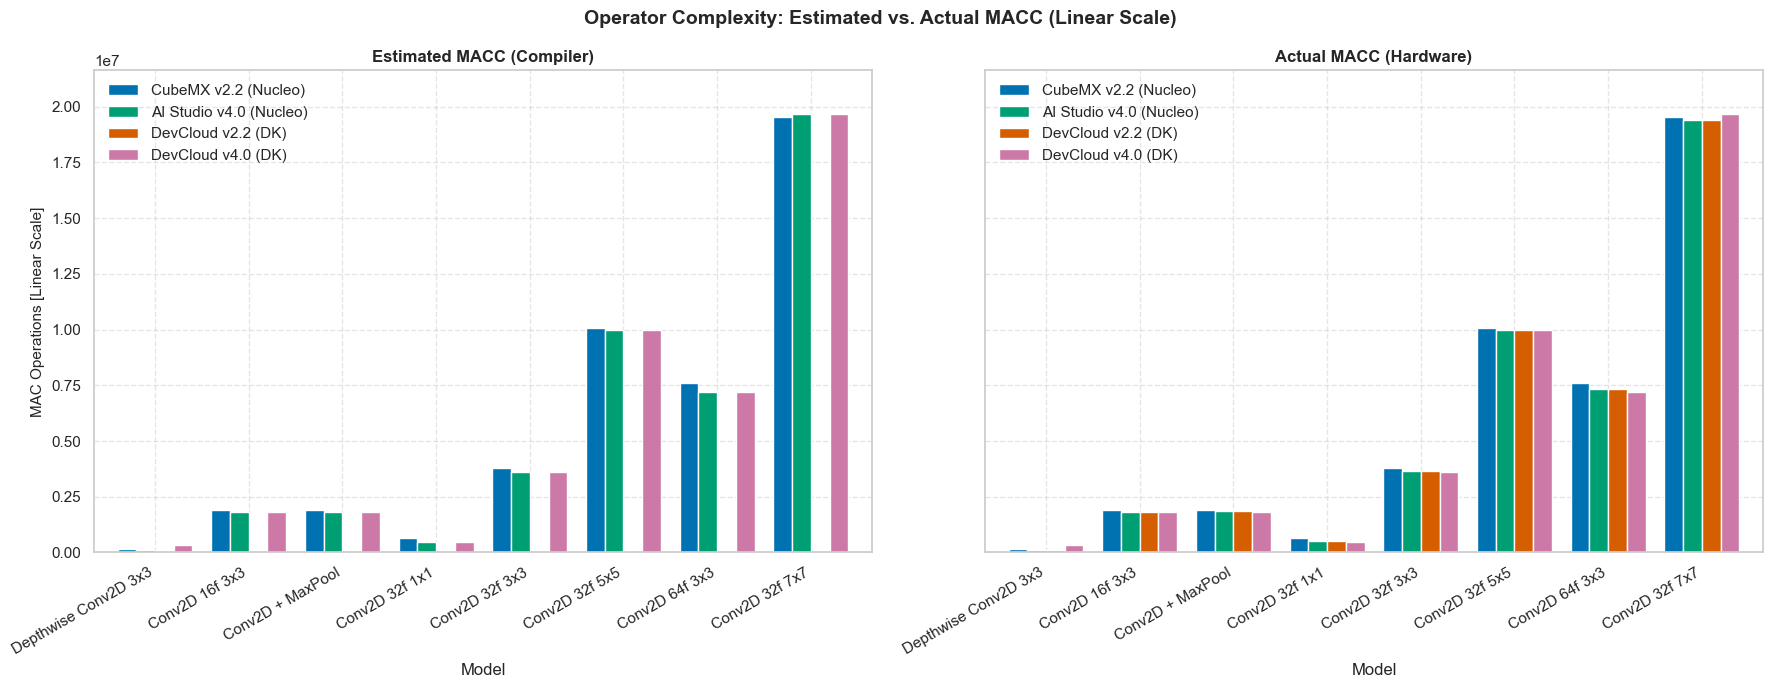

,CubeMX v2.2 (Nucleo),AI Studio v4.0 (Nucleo),DevCloud v2.2 (DK),DevCloud v4.0 (DK)
Model,,,,
Depthwise Conv2D 3x3,135171,116736,0,337920
Conv2D 16f 3x3,1900560,1802240,0,1802240
Conv2D + MaxPool,1916944,1802240,0,1802240
Conv2D 32f 1x1,655392,458752,0,458752
Conv2D 32f 3x3,3801120,3604480,0,3604480
Conv2D 32f 5x5,10092576,9961472,0,9961472
Conv2D 64f 3x3,7602240,7208960,0,7208960
Conv2D 32f 7x7,19529760,19660800,0,19660800


,CubeMX v2.2 (Nucleo),AI Studio v4.0 (Nucleo),DevCloud v2.2 (DK),DevCloud v4.0 (DK)
Model,,,,
Depthwise Conv2D 3x3,135171,122883,122883,337920
Conv2D 16f 3x3,1900560,1835024,1835024,1802240
Conv2D + MaxPool,1916944,1851408,1851408,1802240
Conv2D 32f 1x1,655392,524320,524320,458752
Conv2D 32f 3x3,3801120,3670048,3670048,3604480
Conv2D 32f 5x5,10092576,9961504,9961504,9961472
Conv2D 64f 3x3,7602240,7340096,7340096,7208960
Conv2D 32f 7x7,19529760,19398688,19398688,19660800


In [6]:
# Prepare MACC data
macc_data_est = []
macc_data_act = []

for m in all_models:
    clean_m = get_clean_name(m)
    
    # Estimated
    est_row = {'Model': clean_m}
    for tool_name, df in dfs_est.items():
        row_match = df[df['Model Name'] == m]
        val = row_match.iloc[0]['Estimated MACC'] if not row_match.empty else np.nan
        est_row[tool_name] = pd.to_numeric(val, errors='coerce')
    macc_data_est.append(est_row)
    
    # Actual
    act_row = {'Model': clean_m}
    for tool_name, df in dfs_base.items():
        row_match = df[df['Model Name'] == m]
        val = row_match.iloc[0]['MACC'] if not row_match.empty else np.nan
        act_row[tool_name] = pd.to_numeric(val, errors='coerce')
    macc_data_act.append(act_row)

df_macc_est = pd.DataFrame(macc_data_est).set_index('Model').reindex(columns=col_order_tools)
df_macc_act = pd.DataFrame(macc_data_act).set_index('Model').reindex(columns=col_order_tools)

df_macc_est = df_macc_est.reindex([m for m in model_order if m in df_macc_est.index])
df_macc_act = df_macc_act.reindex([m for m in model_order if m in df_macc_act.index])

# Plotting MACC side-by-side with custom colors
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
colors_macc = [COLOR_MAP[col] for col in df_macc_est.columns]

df_macc_est.plot(kind='bar', ax=axes[0], width=0.8, color=colors_macc)
axes[0].set_title('Estimated MACC (Compiler)', fontweight='bold', fontsize=12)
axes[0].set_ylabel('MAC Operations [Linear Scale]', fontsize=11)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].grid(True, which="both", ls="--", alpha=0.5)

df_macc_act.plot(kind='bar', ax=axes[1], width=0.8, color=colors_macc)
axes[1].set_title('Actual MACC (Hardware)', fontweight='bold', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].grid(True, which="both", ls="--", alpha=0.5)

# Set same y-limit
max_macc = max(df_macc_est.max().max(), df_macc_act.max().max())
axes[0].set_ylim(0, max_macc * 1.1)
axes[1].set_ylim(0, max_macc * 1.1)

plt.suptitle('Operator Complexity: Estimated vs. Actual MACC (Linear Scale)', fontweight='bold', fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/10_macc_estimated_vs_actual_side_by_side.png', dpi=300)
plt.show()

# Display tables stacked vertically for proper PDF formatting
html_macc_est = df_macc_est.style.set_caption("Estimated MACC").format(precision=0).set_properties(**{'text-align': 'center'}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#16a085'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]}
]).to_html()

html_macc_act = df_macc_act.style.set_caption("Actual MACC").format(precision=0).set_properties(**{'text-align': 'center'}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]}
]).to_html()

display_html(html_macc_est, raw=True)
display_html("<br>", raw=True)
display_html(html_macc_act, raw=True)

## 5. Hardware Epochs Partitioning
On the STM32N6 NPU, models can be split into multiple "hardware epochs" to fit within the internal SRAM. A higher number of epochs indicates that intermediate activations or weights had to be tiled and swapped back and forth. The table below lists the epoch partitioning strategy for each tool/compiler.

In [7]:
# Extract hardware epochs from notes
epochs_data = []

def parse_epochs(notes):
    if pd.isna(notes):
        return 'N/A'
    notes_lower = str(notes).lower()
    if 'fail' in notes_lower or 'timeout' in notes_lower:
        return 'FAIL'
    
    if '1 single' in notes_lower or '1 hardware' in notes_lower or 'single hardware' in notes_lower:
        return '1'
    if '2' in notes_lower:
        return '2'
    if '3' in notes_lower:
        return '3'
    if '4' in notes_lower:
        return '4'
        
    import re
    nums = re.findall(r'\d+', notes)
    if nums:
        return nums[0]
        
    return notes

for tool, df in dfs_base.items():
    for _, row in df.iterrows():
        clean_model = get_clean_name(row['Model Name'])
        epoch_str = parse_epochs(row['Notes'])
        epochs_data.append({
            'Tool': tool,
            'Model Name': clean_model,
            'Hardware Epochs': epoch_str
        })

df_epochs = pd.DataFrame(epochs_data)
df_epochs_pivot = df_epochs.pivot(index='Model Name', columns='Tool', values='Hardware Epochs')
df_epochs_pivot = df_epochs_pivot.reindex(columns=col_order_tools)
df_epochs_pivot = df_epochs_pivot.reindex(index=[c for c in model_order if c in df_epochs_pivot.index])

styled_epochs = df_epochs_pivot.style.set_properties(**{
    'text-align': 'center',
    'font-size': '11pt',
    'border': '1px solid lightgrey'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#d35400'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]}
]).set_caption("Hardware Epochs Partitioning by Layer & Tool")

display(styled_epochs)

Tool,CubeMX v2.2 (Nucleo),AI Studio v4.0 (Nucleo),DevCloud v2.2 (DK),DevCloud v4.0 (DK)
Model Name,,,,
Depthwise Conv2D 3x3,2,1,2,1
Conv2D 16f 3x3,1,1,1,1
Conv2D + MaxPool,1,1,1,1
Conv2D 32f 1x1,1,2,1,2
Conv2D 32f 3x3,1,1,1,1
Conv2D 32f 5x5,1,1,1,1
Conv2D 64f 3x3,1,1,1,1
Conv2D 32f 7x7,4,FAIL,4,FAIL


## 6. Comprehensive Platform Statistics & Distributions
This section provides a detailed statistical comparison to identify the overall fastest and most memory-efficient compiler and hardware platform.
- **Summary Tables:** Tables computing Count, Mean, Std Dev, Variance, Min, Medians, Percentiles (25%, 75%, 90%), Max, and Success Rate.
- **Side-by-Side Distribution Box Plots:** Displays the actual variability, standard deviation, and any performance outliers for both Latency (linear scale) and RAM Memory allocation (logarithmic scale) with custom palettes and individual data points overlaid.

,CubeMX v2.2 (Nucleo),AI Studio v4.0 (Nucleo),DevCloud v2.2 (DK),DevCloud v4.0 (DK)
Successful Runs (count),8.0000,7.0000,8.0000,7.0000
Mean / Media (avg),0.1742,0.2113,0.1821,0.1571
Std Dev / Deviaz. Std,0.1374,0.1271,0.1384,0.1007
Minimum / Minimo,0.0420,0.0530,0.0500,0.0310
25th Percentile (P25),0.0798,0.1215,0.0870,0.0870
Median / Mediana (P50),0.1465,0.2080,0.1540,0.1550
75th Percentile (P75),0.1865,0.2960,0.1935,0.2245
Maximum / Massimo,0.4620,0.3830,0.4730,0.2910
Variance / Varianza,0.0189,0.0161,0.0191,0.0101
90th Percentile (P90),0.3374,0.3770,0.3456,0.2892


,CubeMX v2.2 (Nucleo),AI Studio v4.0 (Nucleo),DevCloud v2.2 (DK),DevCloud v4.0 (DK)
Successful Runs (count),8.00,8.00,8.00,8.00
Mean / Media (avg),173.52,116.73,118.39,220.02
Std Dev / Deviaz. Std,451.95,81.07,83.13,538.45
Minimum / Minimo,12.02,17.34,13.07,12.00
25th Percentile (P25),12.03,62.03,62.95,12.02
Median / Mediana (P50),12.03,135.34,136.31,12.03
75th Percentile (P75),15.04,140.69,145.62,44.05
Maximum / Massimo,1292.00,268.70,272.44,1548.00
Variance / Varianza,204260.66,6571.68,6910.02,289928.78
90th Percentile (P90),404.40,179.25,183.97,562.40


/var/folders/qn/y4fdcgw97jsbxdyb6s0d79680000gn/T/ipykernel_4086/1159961139.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/qn/y4fdcgw97jsbxdyb6s0d79680000gn/T/ipykernel_4086/1159961139.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha='right')
/var/folders/qn/y4fdcgw97jsbxdyb6s0d79680000gn/T/ipykernel_4086/1159961139.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/qn/y4fdcgw97jsbxdyb6s0d79680000gn/T/ipykernel_4086/1159961139.py:116: UserWarning: set_ticklabels() should only be used with a fixed number

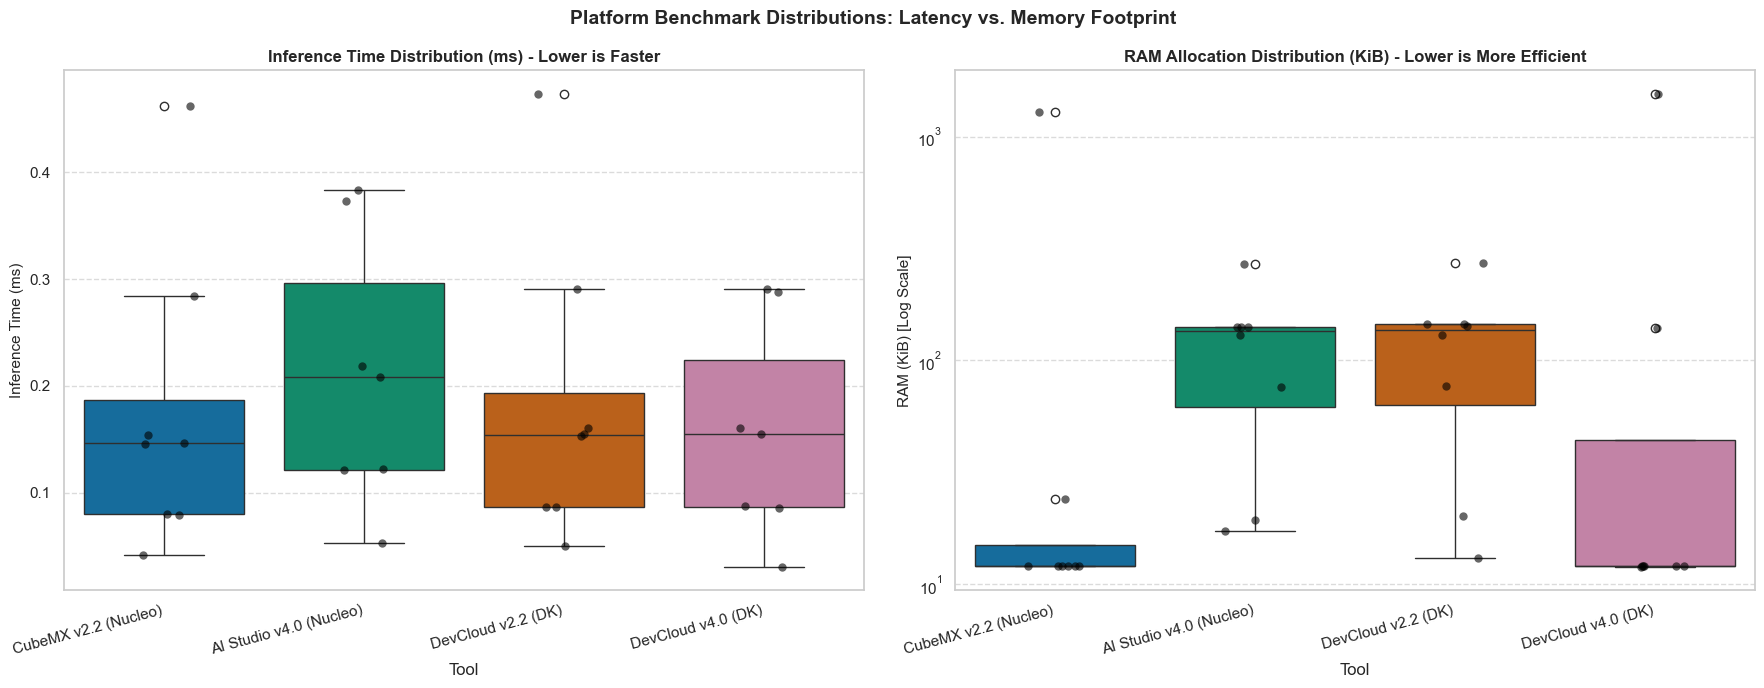

In [8]:
# Compute detailed statistics for successful runs
stats_time_list = []
stats_ram_list = []

for tool, df in dfs_base.items():
    times = df['Inference Time (ms)'].dropna()
    rams = df['RAM Usage (KiB)' ].dropna()
    
    # Calculate Latency Stats
    t_stats = times.describe()
    t_stats['variance'] = times.var()
    t_stats['90%'] = times.quantile(0.9)
    t_stats['success_rate (%)'] = (df['Inference Time (ms)'].notna().sum() / len(df)) * 100
    stats_time_list.append(pd.DataFrame(t_stats).rename(columns={'Inference Time (ms)': tool}))
    
    # Calculate RAM Stats
    r_stats = rams.describe()
    r_stats['variance'] = rams.var()
    r_stats['90%'] = rams.quantile(0.9)
    stats_ram_list.append(pd.DataFrame(r_stats).rename(columns={'RAM Usage (KiB)': tool}))

df_stats_time = pd.concat(stats_time_list, axis=1).reindex(columns=col_order_tools)
df_stats_ram = pd.concat(stats_ram_list, axis=1).reindex(columns=col_order_tools)

stats_rename = {
    'count': 'Successful Runs (count)',
    'mean': 'Mean / Media (avg)',
    'std': 'Std Dev / Deviaz. Std',
    'variance': 'Variance / Varianza',
    'min': 'Minimum / Minimo',
    '25%': '25th Percentile (P25)',
    '50%': 'Median / Mediana (P50)',
    '75%': '75th Percentile (P75)',
    '90%': '90th Percentile (P90)',
    'max': 'Maximum / Massimo',
    'success_rate (%)': 'Success Rate (%)'
}

df_stats_time.rename(index=stats_rename, inplace=True)
df_stats_ram.rename(index=stats_rename, inplace=True)

# Styled HTML tables displayed stacked vertically for proper PDF width compliance
html_stats_time = df_stats_time.style.set_caption("Latency (Inference Time) Summary Statistics").format(precision=4).set_properties(**{'text-align': 'center'}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]}
]).to_html()

html_stats_ram = df_stats_ram.style.set_caption("RAM Memory Allocation Summary Statistics").format(precision=2).set_properties(**{'text-align': 'center'}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]}
]).to_html()

display_html(html_stats_time, raw=True)
display_html("<br>", raw=True)
display_html(html_stats_ram, raw=True)

# Plotting side-by-side boxplots for distributions
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Latency Boxplot (linear scale)
sns.boxplot(
    data=df_all.dropna(subset=['Inference Time (ms)']),
    x='Tool',
    y='Inference Time (ms)',
    ax=axes[0],
    palette=COLOR_MAP,
    order=col_order_tools
)
sns.stripplot(
    data=df_all.dropna(subset=['Inference Time (ms)']),
    x='Tool',
    y='Inference Time (ms)',
    ax=axes[0],
    color='black',
    alpha=0.6,
    size=6,
    jitter=0.15,
    order=col_order_tools
)
axes[0].set_title('Inference Time Distribution (ms) - Lower is Faster', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Inference Time (ms)', fontsize=11)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha='right')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Prepare RAM list for plotting
ram_plot_data = []
for tool, df in dfs_base.items():
    for _, row in df.iterrows():
        ram_plot_data.append({
            'Tool': tool,
            'RAM Usage (KiB)': row['RAM Usage (KiB)']
        })
df_ram_all = pd.DataFrame(ram_plot_data)

# RAM Boxplot (log scale for high range visibility)
sns.boxplot(
    data=df_ram_all.dropna(subset=['RAM Usage (KiB)']),
    x='Tool',
    y='RAM Usage (KiB)',
    ax=axes[1],
    palette=COLOR_MAP,
    order=col_order_tools
)
sns.stripplot(
    data=df_ram_all.dropna(subset=['RAM Usage (KiB)']),
    x='Tool',
    y='RAM Usage (KiB)',
    ax=axes[1],
    color='black',
    alpha=0.6,
    size=6,
    jitter=0.15,
    order=col_order_tools
)
axes[1].set_title('RAM Allocation Distribution (KiB) - Lower is More Efficient', fontweight='bold', fontsize=12)
axes[1].set_ylabel('RAM (KiB) [Log Scale]', fontsize=11)
axes[1].set_yscale('log')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha='right')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Platform Benchmark Distributions: Latency vs. Memory Footprint', fontweight='bold', fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/12_latency_vs_ram_distributions.png', dpi=300)
plt.show()